Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Creating the data frame

In [4]:
DataFrame = pd.read_csv("ZomatoData.csv")
print(DataFrame)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [5]:
print(f"shape of data ",DataFrame.shape)

print(DataFrame.head())

shape of data  (148, 7)
                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [6]:
print("Columns in data frame: \n",DataFrame.columns)

Columns in data frame: 
 Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')


In [7]:
print(DataFrame.describe())

             votes  approx_cost(for two people)
count   148.000000                   148.000000
mean    264.810811                   418.243243
std     653.676951                   223.085098
min       0.000000                   100.000000
25%       6.750000                   200.000000
50%      43.500000                   400.000000
75%     221.750000                   600.000000
max    4884.000000                   950.000000


In [8]:
print(DataFrame.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None


In [9]:
print(DataFrame.head(5))

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


Data Cleaning and Preparation

1. Convert the rate column to a float by removing denominator characters

In [10]:
def HandleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

DataFrame['rate'] = DataFrame['rate'].apply(HandleRate)

In [11]:
print(DataFrame.head(5))

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


2. Getting summry of the dataframe

In [12]:
DataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


3. Checking for Missing or null values

In [13]:
print(DataFrame.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


**Exploring Restaurant Types**

Identify popular restaurant categories

Text(0.5, 0, 'Type of restaurant')

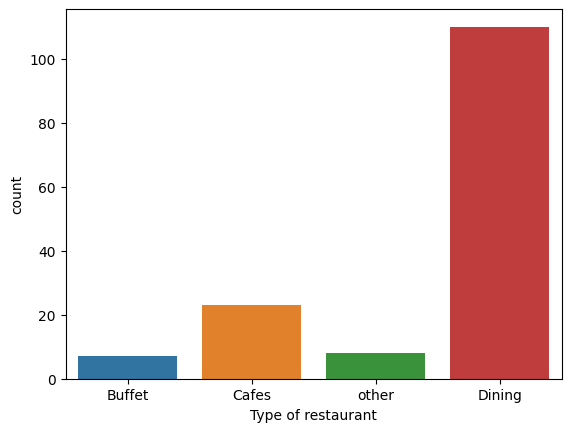

In [14]:
sns.countplot(x=DataFrame['listed_in(type)'])
plt.xlabel("Type of restaurant")

*The majority of the restaurants fall into the dining category*

2. Votes by Restaurant Type

Text(0, 0.5, 'Votes')

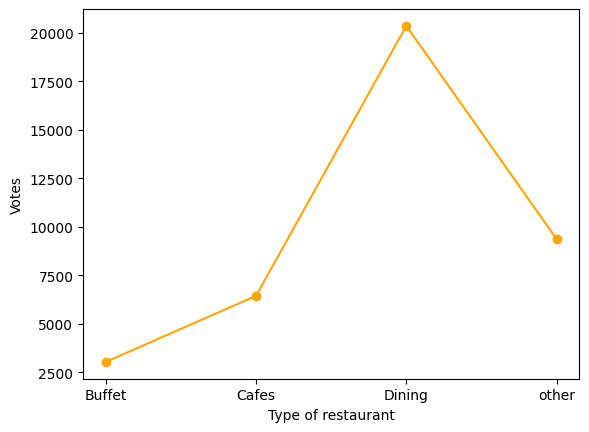

In [15]:
group_data = DataFrame.groupby('listed_in(type)')['votes'].sum()
res = pd.DataFrame({'votes':group_data})
plt.plot(res,c='Orange',marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

*Dining restaurant are preferred by a larger number of individuals.*

**Identify the Most Voted Restaurant**

In [16]:
max_votes = DataFrame['votes'].max()

restaurant_with_max_votes = DataFrame.loc[DataFrame['votes']==max_votes,'name']

print('Restaurant(s) with the maximum votes: ')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes: 
38    Empire Restaurant
Name: name, dtype: object


**Online Order Availability**



<Axes: xlabel='online_order', ylabel='count'>

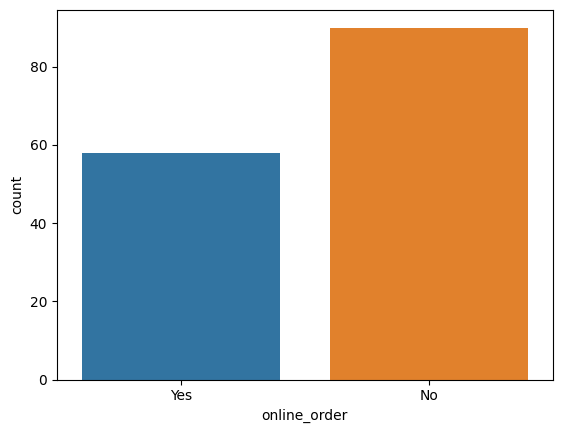

In [17]:
sns.countplot(x=DataFrame['online_order'])

*This suggests that a majority of the restaurants do not accept online orders.*

**Analyze Ratings**

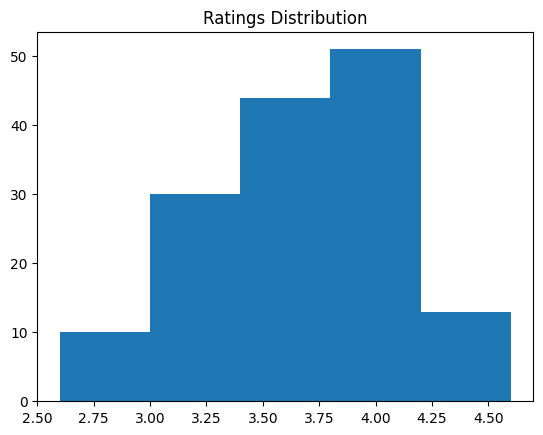

In [18]:
plt.hist(DataFrame['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

*The majority of restaurants received ratings ranging from 3.5 to 4.*

**Approximate Cost of Couples**

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

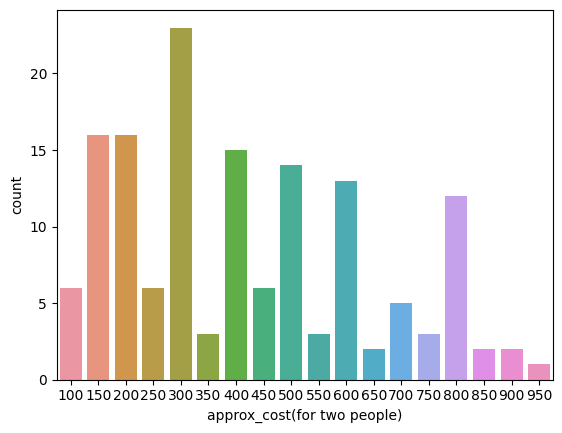

In [19]:
couple_data = DataFrame['approx_cost(for two people)']
sns.countplot(x=couple_data)

*The majority of couples prefer restaurants with an approximate cost of 300 rupees.*

**Ratings Comparison - Online vs Offline Orders**

<Axes: xlabel='online_order', ylabel='rate'>

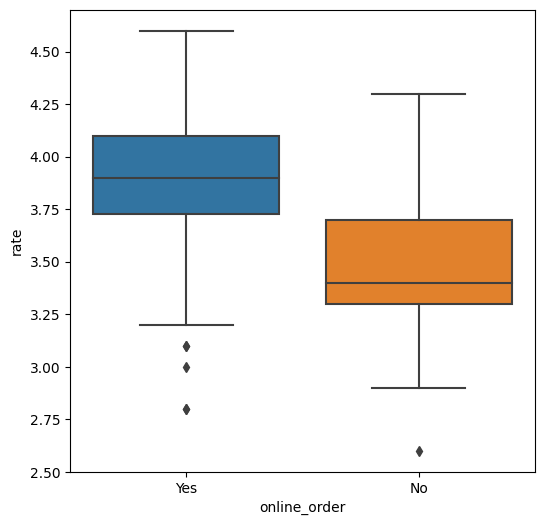

In [20]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=DataFrame)

*Offline orders received lower ratings in comparison to online orders which obtained excellent ratings.*

**Order Mode Preferences by Restaurant Type**

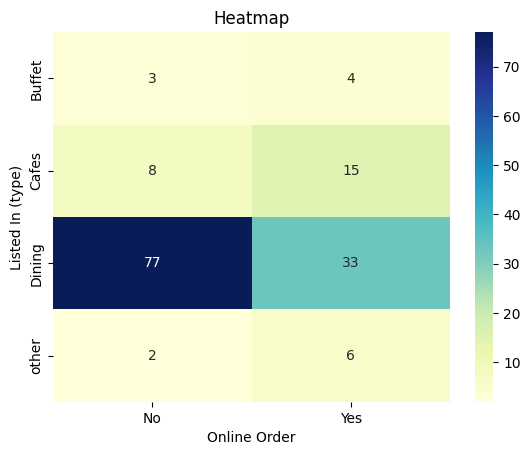

In [21]:
pivot_table = DataFrame.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu',fmt='d')

plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (type)')
plt.show()

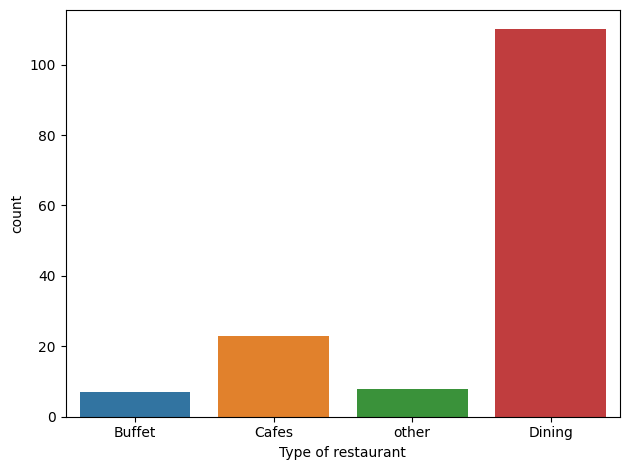

In [22]:
sns.countplot(x=DataFrame['listed_in(type)'])
plt.xlabel("Type of restaurant")
plt.tight_layout()

plt.savefig("restaurant_type_countplot.png", dpi=300)

plt.show()